# Evaluation of CLIP model

Rewritten our old evaluation code (pure python) to ipynb. Accuracy and F1-score added.

In [33]:
import json
from pathlib import Path
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import open_clip

## Configuration

In [34]:
# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Paths
IMAGE_DIR = "RSICD_images"
DATA_C_JSON = "processed_data/dataC.json"
MODEL_PATH = "clip_trained_model.pt"

# Evaluation settings
BATCH_SIZE = 64
NUM_WORKERS = 0

Using device: cuda


## Load CLIP model

In [35]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai",
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")

Model loaded.


## Load Split C

In [36]:
with open(DATA_C_JSON, "r") as f:
    dataC = json.load(f)["images"]

print(f"Number of Split C images: {len(dataC)}")
print(dataC[0])

Number of Split C images: 1093
{'filename': 'airport_348.jpg', 'imgid': 276, 'sentences': [{'tokens': ['the', 'airport', 'is', 'very', 'large'], 'raw': 'the airport is very large .', 'imgid': 276, 'sentid': 1380}, {'tokens': ['next', 'to', 'the', 'airport', 'is', 'green', 'grass'], 'raw': 'next to the airport is green grass .', 'imgid': 276, 'sentid': 1381}, {'tokens': ['next', 'to', 'the', 'airport', 'is', 'green', 'grass'], 'raw': 'next to the airport is green grass .', 'imgid': 276, 'sentid': 1382}, {'tokens': ['the', 'airport', 'is', 'very', 'large'], 'raw': 'the airport is very large .', 'imgid': 276, 'sentid': 1383}, {'tokens': ['the', 'airport', 'is', 'very', 'large'], 'raw': 'the airport is very large .', 'imgid': 276, 'sentid': 1384}], 'split': 'test', 'sentids': [1380, 1381, 1382, 1383, 1384], 'label': 'Airport'}


## Build class prompts

In [37]:
class_names = sorted({item["label"] for item in dataC if item["label"] != "Unknown"})

prompts = [f"a satellite image of {name}" for name in class_names]
text_tokens = tokenizer(prompts).to(DEVICE)

print(f"Number of classes: {len(class_names)}")
print(class_names)
print(prompts[:5])

Number of classes: 31
['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge', 'Center', 'Church', 'Commercial', 'DenseResidential', 'Desert', 'Farmland', 'Forest', 'Industrial', 'Meadow', 'MediumResidential', 'Mountain', 'Park', 'Parking', 'Playground', 'Pond', 'Port', 'RailwayStation', 'Resort', 'River', 'School', 'SparseResidential', 'Square', 'Stadium', 'StorageTanks', 'Viaduct', 'playfields']
['a satellite image of Airport', 'a satellite image of BareLand', 'a satellite image of BaseballField', 'a satellite image of Beach', 'a satellite image of Bridge']


## Embed class prompts

Text embeddings are normalized so dot products between image and text embeddings become cosine similarities.

In [38]:
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=-1)

print(text_features.shape)

torch.Size([31, 512])


## Dataset and DataLoader

In [39]:
class RSICDImageDataset(Dataset):
    def __init__(self, items, image_dir, preprocess):
        self.items = items
        self.image_dir = Path(image_dir)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image_path = self.image_dir / item["filename"]

        image = Image.open(image_path).convert("RGB")
        image = self.preprocess(image)

        label = item["label"]
        return image, label, item["filename"]


test_dataset = RSICDImageDataset(dataC, IMAGE_DIR, preprocess)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Number of batches: {len(test_loader)}")

Number of batches: 18


## Predict with image-text similarity

In [40]:
all_preds = []
all_labels = []
all_filenames = []

with torch.no_grad():
    for images, labels, filenames in test_loader:
        images = images.to(DEVICE)

        image_features = model.encode_image(images)
        image_features = F.normalize(image_features, dim=-1)

        logits = image_features @ text_features.T
        pred_indices = logits.argmax(dim=1)

        preds = [class_names[i] for i in pred_indices.cpu().tolist()]

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_filenames.extend(filenames)

print(f"Predicted {len(all_preds)} images.")

Predicted 1093 images.


## Accuracy

In [41]:
accuracy = sum(p == y for p, y in zip(all_preds, all_labels)) / len(all_labels)
print(f"Zero-shot accuracy: {accuracy:.4f}")

Zero-shot accuracy: 0.7246


## Macro F1-score

In [42]:
class_to_idx = {c: i for i, c in enumerate(class_names)}
y_true = [class_to_idx[y] for y in all_labels]
y_pred = [class_to_idx[p] for p in all_preds]

num_classes = len(class_names)

tp = [0] * num_classes
fp = [0] * num_classes
fn = [0] * num_classes

for t, p in zip(y_true, y_pred):
    tp[t] += int(t == p)
    fp[p] += int(t != p)
    fn[t] += int(t != p)

f1 = 0.0
for i in range(num_classes):
    prec = tp[i] / (tp[i] + fp[i] + 1e-8)
    rec = tp[i] / (tp[i] + fn[i] + 1e-8)
    f1 += 2 * prec * rec / (prec + rec + 1e-8)

macro_f1 = f1 / num_classes
print(f"F1-Score: {macro_f1:.4f}")

F1-Score: 0.7103


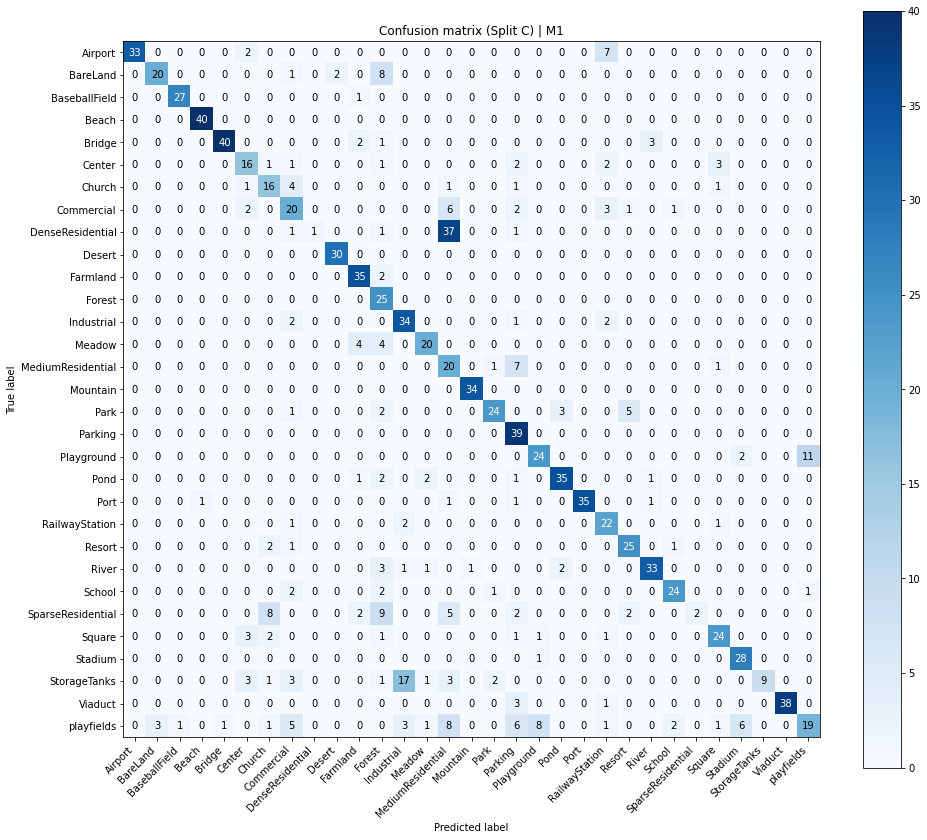

In [45]:
import numpy as np
import itertools
import matplotlib.pyplot as plt


#Build confusion matrix
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

#Plotting
normalize = False
cmap = plt.cm.Blues

if normalize:
    cm_plot = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
else:
    cm_plot = cm

plt.figure(figsize=(14, 12))
plt.imshow(cm_plot, interpolation="nearest", cmap=cmap)
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm_plot.max() / 2.0
fmt = ".2f" if normalize else "d"
for i, j in itertools.product(range(cm_plot.shape[0]), range(cm_plot.shape[1])):
    plt.text(j, i, format(cm_plot[i, j], fmt),
             horizontalalignment="center",
             verticalalignment="center",
             color="white" if cm_plot[i, j] > thresh else "black")

acc = 100 * (np.trace(cm) / np.sum(cm))
plt.title("Confusion matrix (Split C) | M1")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches="tight")
plt.show()

## Inspect predictions

In [31]:
for filename, label, pred in list(zip(all_filenames, all_labels, all_preds))[:10]:
    print(f"{filename:30s} true={label:20s} pred={pred}")

airport_348.jpg                true=Airport              pred=Airport
airport_349.jpg                true=Airport              pred=Airport
airport_35.jpg                 true=Airport              pred=Airport
airport_350.jpg                true=Airport              pred=Airport
airport_351.jpg                true=Airport              pred=RailwayStation
airport_352.jpg                true=Airport              pred=Airport
airport_353.jpg                true=Airport              pred=Airport
airport_354.jpg                true=Airport              pred=Airport
airport_355.jpg                true=Airport              pred=Airport
airport_356.jpg                true=Airport              pred=Airport


## Optional: save predictions

In [32]:
output_path = "results/testname.txt"

with open(output_path, "w") as f:
    f.write(f"Accuracy: {accuracy*100}% \nF1-Score: {macro_f1*100}%")

print(f"Saved predictions to {output_path}")

Saved predictions to results/testname.txt
